In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from  sklearn.model_selection import train_test_split
from  sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error,r2_score


In [ ]:
df=pd.read_csv('Ice_cream selling data.csv')
df

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531
5,-3.455712,30.001138
6,-3.108440,22.635401
7,-3.081303,25.365022
8,-2.672461,19.226970
9,-2.652287,20.279679


In [ ]:
df.corr()

,Temperature (°C),Ice Cream Sales (units)
Temperature (°C),1.000000,-0.175184
Ice Cream Sales (units),-0.175184,1.000000


Data is 'linear' or 'non-linear'

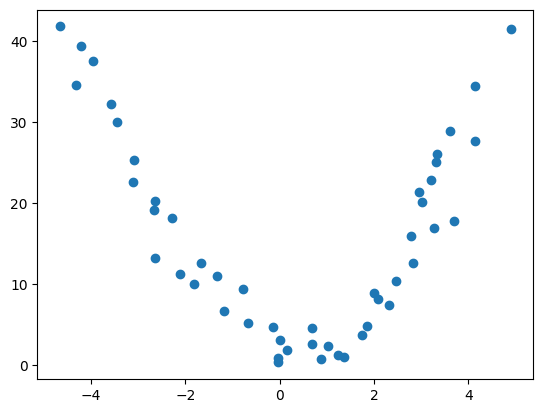

In [ ]:
plt.scatter(df['Temperature (°C)'],df['Ice Cream Sales (units)'] )

In [ ]:
x=df[['Temperature (°C)']]
y=df['Ice Cream Sales (units)']

In [ ]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,train_size=0.8,random_state=42)
train_test_split(x,y,train_size=0.8,random_state=42)

[    Temperature (°C)
 12         -2.111870
 4          -3.578554
 34          2.318591
 8          -2.672461
 3          -3.949661
 6          -3.108440
 40          3.211366
 41          3.270044
 46          4.130868
 15         -1.326379
 9          -2.652287
 16         -1.173123
 24          0.688781
 33          2.075101
 30          1.740000
 0          -4.662263
 43          3.335932
 32          1.999310
 5          -3.455712
 29          1.359813
 11         -2.288264
 36          2.784836
 1          -4.316559
 21         -0.033895
 2          -4.213985
 37          2.831760
 35          2.471946
 23          0.149245
 39          3.020874
 10         -2.651498
 22          0.008608
 18         -0.673753
 48          4.899032
 20         -0.036156
 7          -3.081303
 42          3.316073
 14         -1.660348
 28          1.240712
 38          2.959932,
     Temperature (°C)
 13         -1.818938
 45          3.704057
 47          4.133534
 44          3.610778
 17      

### Model Creation and Training

In [ ]:
model=LinearRegression()
model.fit(xtrain,ytrain)# learns the patterns(mx+c) from xtrain and ytrain
model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[-1.15]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Temperature (°C)']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,17.14
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


### Model Evaluation

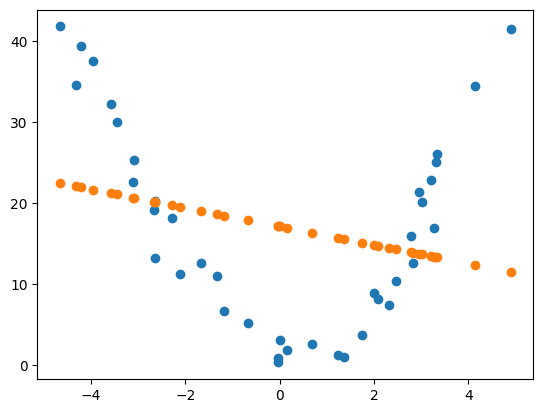

In [ ]:
ypred_train=model.predict(xtrain)
plt.scatter(xtrain,ytrain)
plt.scatter(xtrain,ypred_train)

## train data

In [ ]:
ypred_train=model.predict(xtrain)
score=r2_score(ytrain,ypred_train)
score


0.06579063815950037

### Polynomial Features

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=3)
updated_xtrain=poly.fit_transform(xtrain)
updated_xtest=poly.transform(xtest)

In [ ]:
xtrain

,Temperature (°C)
12,-2.111870
4,-3.578554
34,2.318591
8,-2.672461
3,-3.949661
6,-3.108440
40,3.211366
41,3.270044
46,4.130868
15,-1.326379


In [ ]:
updated_xtrain[:,1]

array([-2.11186969, -3.57855372,  2.31859124, -2.67246083, -3.94966109,
       -3.10844012,  3.21136614,  3.27004407,  4.13086796, -1.32637898,
       -2.65228679, -1.17312327,  0.68878091,  2.0751006 ,  1.74000001,
       -4.66226268,  3.33593241,  1.99931037, -3.4557117 ,  1.35981267,
       -2.288264  ,  2.78483646, -4.31655945, -0.03389529, -4.21398476,
        2.83176021,  2.471946  ,  0.14924457,  3.02087431, -2.65149803,
        0.0086077 , -0.6737528 ,  4.89903151, -0.0361565 , -3.08130332,
        3.31607252, -1.66034773,  1.24071162,  2.95993209])

In [ ]:
model=LinearRegression()
model.fit(updated_xtrain,ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[ 0. ,-1.4 , 1.88, 0.05]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.841
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,3
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](4,)","[244.86, 38.67, 7.47, 0. ]"


In [ ]:
##Ypred_train=model.predict(Xtrain)
###ValueError: X has 3 features, but LinearRegression is expecting 4 features as input.



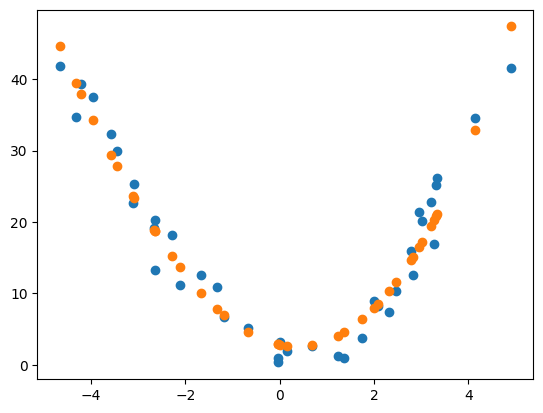

In [ ]:
ypred_train=model.predict(updated_xtrain)
plt.scatter(updated_xtrain[:,1],ytrain)
plt.scatter(updated_xtrain[:,1],ypred_train)

## Training Data

##### R2 score

In [ ]:
# train score
ypred_train=model.predict(updated_xtrain)
train_score=r2_score(ytrain,ypred_train)
print(f"Train Score : {train_score}")

Train Score : 0.9469116778215552


In [ ]:
#test score
ypred_test=model.predict(updated_xtest)
test_score=r2_score(ytest,ypred_test)
print(f"Test Score : {test_score}")

Test Score : 0.8405107685716915


#### Mean Absolute Error

In [ ]:
Mae=mean_absolute_error(ytrain,ypred_train)
print(f"Mae : {Mae}")

Mae : 2.43566416014849


In [ ]:
Mae=mean_absolute_error(ytest,ypred_test)
print(f"Mae : {Mae}")

Mae : 3.228121129776889


#### Root Mean Squared Error

In [ ]:
Rmse=root_mean_squared_error(ytrain,ypred_train)
print(f"Rmse : {Rmse}")

Rmse : 2.8539631962901724


In [ ]:
Rmse=root_mean_squared_error(ytest,ypred_test)
print(f"Rmse : {Rmse}")

Rmse : 3.888445634341502


degree=1

R2 score--> Train Score : 0.06579063815950059     Test Score : -0.5751270190188227

MAE-------> Train Score : 10.136398159361041      Test score : 11.752026695440602

RMSE------> Train Score : 11.972117646423852      Test Score : 11.972117646423852


degree=2

R2 Score-->Train Score : 0.9413665676490518      Test Score : 0.843055137193884

MAE-------> Train Score : 2.5993732834161136      Test score : 3.2299819836597274

RMSE------> Train Score : 2.99931118717202      Test Score : 3.857304297171988

degree=3

R2 score-->Train Score : 0.9469116778215552      Test Score : 0.8405107685716915

MAE-------> Train Score : 2.43566416014849      Test score : 3.228121129776889

RMSE------> Train Score : 2.8539631962901724      Test Score : 3.888445634341502

degree=4

R2 Score-->Train Score : 0.9590068634754769     Test Score : 0.8054468908427623

MAE-------> Train Score : 2.0963498651499717      Test score : 3.43761854085144

RMSE------> Train Score : 2.507866665138919       Test Score : 2.507866665138919

If the polynomial is not performing well we go for tree-based

###